In [1]:
# Seaweed import multi_algae_real
!pip install geopandas matplotlib
!pip install geodatasets
!pip install rioxarray

In [3]:
import copernicusmarine
from netCDF4 import Dataset, num2date
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import os
import xarray as xr
import rioxarray as rxr
import seaborn as sns
import seaborn.objects as so
import numpy as np
import gc
from datetime import datetime
import glob
from scipy import stats
from scipy.stats import linregress
import geopandas as gpd
import geodatasets
from shapely.geometry import Point
from shapely.geometry import MultiPolygon

# KD490

In [3]:
file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/*.nc'))
all_ds = xr.open_mfdataset(file_list, concat_dim='time', combine='nested')
## combine all the files into one, massive DataSet so that we can do comparisons over years
all_ds

<xarray.Dataset> Size: 54GB
Dimensions:    (time: 10228, latitude: 1056, longitude: 1248)
Coordinates:
  * time       (time) datetime64[ns] 82kB 1997-09-04 1997-09-05 ... 2025-09-04
  * latitude   (latitude) float32 4kB 48.01 48.02 48.03 ... 58.97 58.98 58.99
  * longitude  (longitude) float32 5kB -14.99 -14.98 -14.97 ... -2.016 -2.005
Data variables:
    KD490      (time, latitude, longitude) float32 54GB dask.array<chunksize=(119, 1056, 1248), meta=np.ndarray>
Attributes:
    references:                http://www.globcolour.info GlobColour has been...
    contact:                   servicedesk.cmems@acri-st.fr
    Conventions:               CF-1.8, ACDD-1.3
    source:                    surface observation
    history:                   Created using software developed at ACRI-ST
    comment:                   average
    institution:               ACRI
    title:                     cmems_obs-oc_atl_bgc-transp_my_l3-multi-1km_P1D
    copernicusmarine_version:  2.2.2

In [4]:
weekly = all_ds['KD490'].resample(time='1W').mean()
monthly_kd490 = all_ds['KD490'].resample(time='1ME').mean()
seasonal_kd490 = all_ds['KD490'].resample(time='QS-DEC').mean()
seasonal_kd490['season'] = seasonal_kd490['time'].dt.season


In [5]:
stat_trend_ds = xr.open_dataset('KD490_trend_with_stats.nc') ## this is weekly trends

In [6]:
significant = stat_trend_ds['pvalue'] < 0.05  # 95% confidence
trend_sig = stat_trend_ds['slope'].where(significant)

In [7]:
seasonal_ds = xr.open_dataset('KD490_seasonal_trends.nc')

In [8]:
significant_w_seasons = seasonal_ds['pvalue'] < 0.05  # 95% confidence
trend_sig_seasons = seasonal_ds['slope'].where(significant_w_seasons)

# Chlorophyll

In [9]:
chla_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/chlorophyll/*.nc'))
chla_ds = xr.open_mfdataset(chla_file_list, concat_dim='time', combine='nested')
chla_ds

<xarray.Dataset> Size: 54GB
Dimensions:    (time: 10228, latitude: 1056, longitude: 1248)
Coordinates:
  * time       (time) datetime64[ns] 82kB 1997-09-04 1997-09-05 ... 2025-09-04
  * latitude   (latitude) float32 4kB 48.01 48.02 48.03 ... 58.97 58.98 58.99
  * longitude  (longitude) float32 5kB -14.99 -14.98 -14.97 ... -2.016 -2.005
Data variables:
    CHL        (time, latitude, longitude) float32 54GB dask.array<chunksize=(119, 1056, 1248), meta=np.ndarray>
Attributes:
    institution:               ACRI
    comment:                   average
    contact:                   servicedesk.cmems@acri-st.fr
    source:                    surface observation
    history:                   Created using software developed at ACRI-ST
    Conventions:               CF-1.8, ACDD-1.3
    title:                     cmems_obs-oc_atl_bgc-plankton_my_l3-multi-1km_P1D
    references:                http://www.globcolour.info GlobColour has been...
    copernicusmarine_version:  2.2.2

In [10]:
weekly_chla = chla_ds['CHL'].resample(time='1W').mean()
monthly_chla = chla_ds['CHL'].resample(time='1ME').mean()
seasonal_chla = chla_ds['CHL'].resample(time='QS-DEC').mean()
seasonal_chla['season'] = seasonal_chla['time'].dt.season

In [11]:
weekly_trend_chla = xr.open_dataset('Chl_a_trend_with_stats.nc')

In [12]:
w_significant_chla = weekly_trend_chla['pvalue'] < 0.05  # 95% confidence
w_trend_sig_chla = weekly_trend_chla['slope'].where(w_significant_chla)

In [13]:
seasonal_trend_chla = xr.open_dataset('Chl_a_seasonal_trends.nc')

In [14]:
sea_significant_chla = seasonal_trend_chla['pvalue'] < 0.05  # 95% confidence
sea_trend_sig_chla =seasonal_trend_chla['slope'].where(sea_significant_chla)

# CDOM

In [15]:
cdom_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/CDOM/*.nc'))
cdom_ds = xr.open_mfdataset(cdom_file_list, concat_dim='time', combine='nested')
display(cdom_ds)

<xarray.Dataset> Size: 54GB
Dimensions:    (time: 10228, latitude: 1056, longitude: 1248)
Coordinates:
  * time       (time) datetime64[ns] 82kB 1997-09-04 1997-09-05 ... 2025-09-04
  * latitude   (latitude) float32 4kB 48.01 48.02 48.03 ... 58.97 58.98 58.99
  * longitude  (longitude) float32 5kB -14.99 -14.98 -14.97 ... -2.016 -2.005
Data variables:
    CDM        (time, latitude, longitude) float32 54GB dask.array<chunksize=(119, 1056, 1248), meta=np.ndarray>
Attributes:
    contact:                   servicedesk.cmems@acri-st.fr
    Conventions:               CF-1.8, ACDD-1.3
    source:                    surface observation
    institution:               ACRI
    title:                     cmems_obs-oc_atl_bgc-optics_my_l3-multi-1km_P1D
    history:                   Created using software developed at ACRI-ST
    comment:                   average
    references:                http://www.globcolour.info GlobColour has been...
    copernicusmarine_version:  2.2.2

In [16]:
weekly_cdom = cdom_ds['CDM'].resample(time='1W').mean( skipna=True)
monthly_cdom = cdom_ds['CDM'].resample(time='1ME').mean( skipna=True)
seasonal_cdom = cdom_ds['CDM'].resample(time='QS-DEC').mean(skipna=True)
seasonal_cdom['season'] = seasonal_cdom['time'].dt.season

In [17]:
weekly_trend_cdom = xr.open_dataset('CDOM_trend_with_stats.nc')

In [18]:
w_significant_cdom = weekly_trend_cdom['pvalue'] < 0.05  # 95% confidence
w_trend_sig_cdom = weekly_trend_cdom['slope'].where(w_significant_cdom)

In [19]:
seasonal_trend_cdom = xr.open_dataset('CDOM_seasonal_trends.nc')

In [20]:
sea_significant_cdom = seasonal_trend_cdom['pvalue'] < 0.05  # 95% confidence
sea_trend_sig_cdom = seasonal_trend_cdom['slope'].where(sea_significant_cdom)

# SPM

In [21]:
spm_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/SPM/*.nc'))
spm_ds = xr.open_mfdataset(spm_file_list, concat_dim='time', combine='nested')
display(spm_ds)

<xarray.Dataset> Size: 54GB
Dimensions:    (time: 10228, latitude: 1056, longitude: 1248)
Coordinates:
  * time       (time) datetime64[ns] 82kB 1997-09-04 1997-09-05 ... 2025-09-04
  * latitude   (latitude) float32 4kB 48.01 48.02 48.03 ... 58.97 58.98 58.99
  * longitude  (longitude) float32 5kB -14.99 -14.98 -14.97 ... -2.016 -2.005
Data variables:
    SPM        (time, latitude, longitude) float32 54GB dask.array<chunksize=(119, 1056, 1248), meta=np.ndarray>
Attributes:
    title:                     cmems_obs-oc_atl_bgc-transp_my_l3-multi-1km_P1D
    comment:                   average
    source:                    surface observation
    Conventions:               CF-1.8, ACDD-1.3
    references:                http://www.globcolour.info GlobColour has been...
    contact:                   servicedesk.cmems@acri-st.fr
    history:                   Created using software developed at ACRI-ST
    institution:               ACRI
    copernicusmarine_version:  2.2.2

In [22]:
weekly_spm = spm_ds['SPM'].resample(time='1W').mean(skipna=True)
monthly_spm = spm_ds['SPM'].resample(time='1ME').mean(skipna=True)
seasonal_spm = spm_ds['SPM'].resample(time='QS-DEC').mean(skipna=True)
seasonal_spm['season'] = seasonal_spm['time'].dt.season

weekly_trend_spm = xr.open_dataset('SPM_trend_with_stats.nc')

w_significant_spm = weekly_trend_spm['pvalue'] < 0.05  # 95% confidence
w_trend_sig_spm = weekly_trend_spm['slope'].where(w_significant_spm)

seasonal_trend_spm = xr.open_dataset('SPM_seasonal_trends.nc')

sea_significant_spm = seasonal_trend_spm['pvalue'] < 0.05  # 95% confidence
sea_trend_sig_spm = seasonal_trend_spm['slope'].where(sea_significant_spm)

# Analysis
- Which correlates with KD490 more: Chl, CDOM, or SPM?
- When is the spring bloom occuring, and is it happening sooner and for longer?
- How is temperature playing a role?

## Medians, Means, and General Line Up of Components

In [23]:
## looking at medians and means over months and years of the three variables to see what aligns

## medians
chla_year_median = chla_ds['CHL'].quantile(0.5,dim=['latitude','longitude']).groupby('time.year').quantile(0.5, dim='time')

C:\Users\25298423\PycharmProjects\JupyterProject1\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


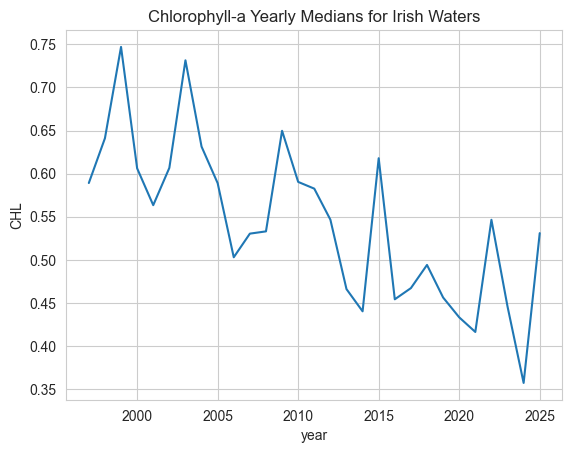

C:\Users\25298423\PycharmProjects\JupyterProject1\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [24]:
chla_year_median.plot()
plt.title('Chlorophyll-a Yearly Medians for Irish Waters')
plt.show()

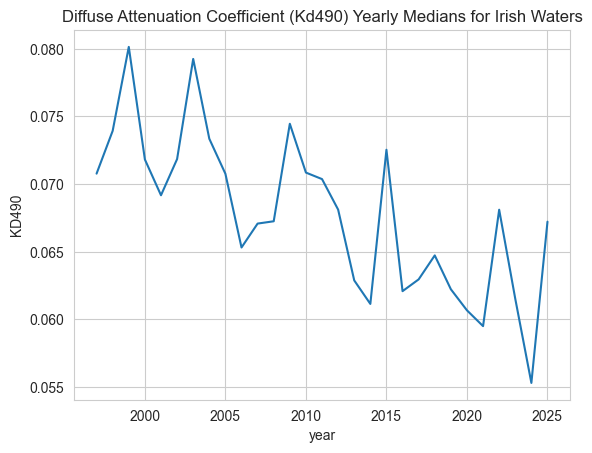

In [25]:
kd490_year_median = all_ds['KD490'].quantile(0.5, dim=['latitude', 'longitude']).groupby('time.year').quantile(0.5,dim='time')

kd490_year_median.plot()
plt.title('Diffuse Attenuation Coefficient (Kd490) Yearly Medians for Irish Waters')
plt.show()

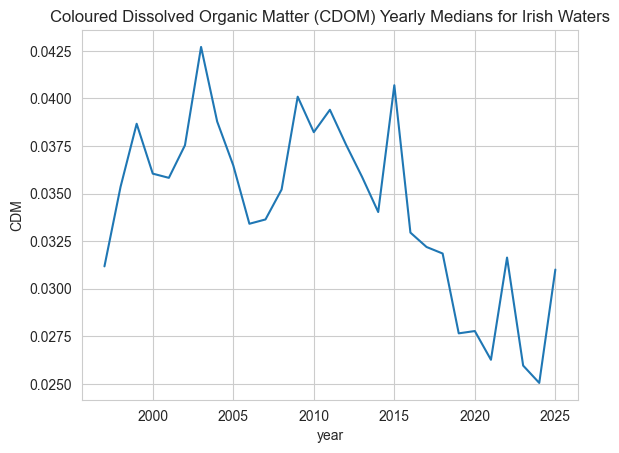

In [26]:
cdom_year_median = cdom_ds['CDM'].quantile(0.5, dim=['latitude', 'longitude']).groupby('time.year').quantile(0.5,dim='time')

cdom_year_median.plot()
plt.title('Coloured Dissolved Organic Matter (CDOM) Yearly Medians for Irish Waters')
plt.show()

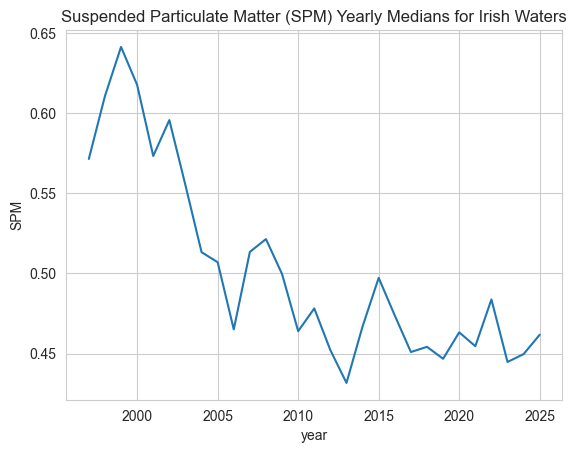

In [27]:
spm_year_median = spm_ds['SPM'].quantile(0.5, dim=['latitude', 'longitude']).groupby('time.year').quantile(0.5,dim='time')
spm_year_median.plot()
plt.title('Suspended Particulate Matter (SPM) Yearly Medians for Irish Waters')
plt.show()

## Means

In [28]:

chla_year_mean = chla_ds['CHL'].mean(dim=['latitude', 'longitude']).groupby('time.year').mean(dim='time')

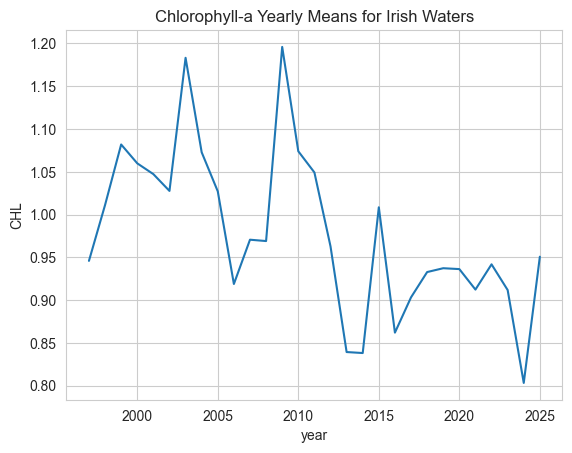

In [29]:
chla_year_mean.plot()
plt.title('Chlorophyll-a Yearly Means for Irish Waters')
plt.show()

In [30]:
chla_month_mean = chla_ds['CHL'].mean(dim=['latitude', 'longitude']).groupby('time.month').mean(dim='time')

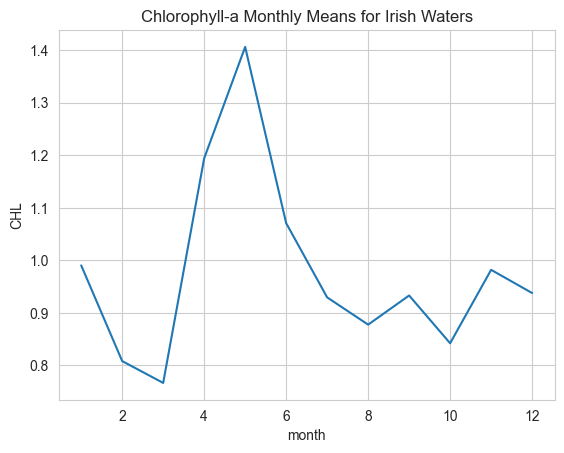

In [31]:
chla_month_mean.plot()
plt.title('Chlorophyll-a Monthly Means for Irish Waters')
plt.show()

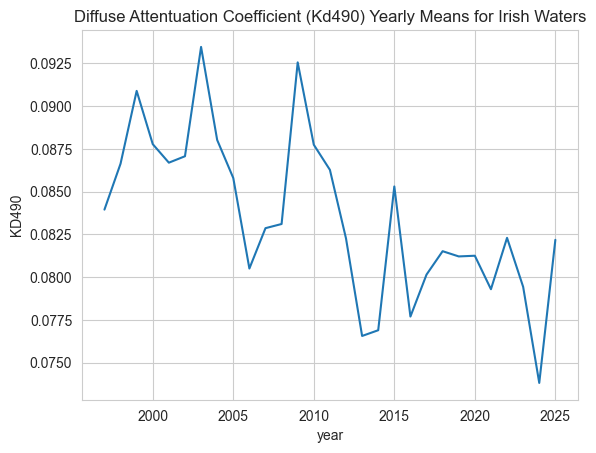

In [32]:
kd490_year_mean = all_ds['KD490'].mean(dim=['latitude', 'longitude']).groupby('time.year').mean(dim='time')
kd490_year_mean.plot()
plt.title('Diffuse Attentuation Coefficient (Kd490) Yearly Means for Irish Waters')
plt.show()

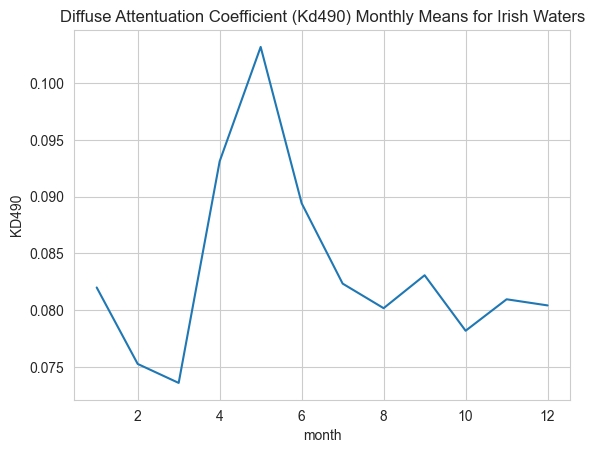

In [33]:
kd490_month_mean = all_ds['KD490'].mean(dim=['latitude', 'longitude']).groupby('time.month').mean(dim='time')
kd490_month_mean.plot()
plt.title('Diffuse Attentuation Coefficient (Kd490) Monthly Means for Irish Waters')
plt.show()

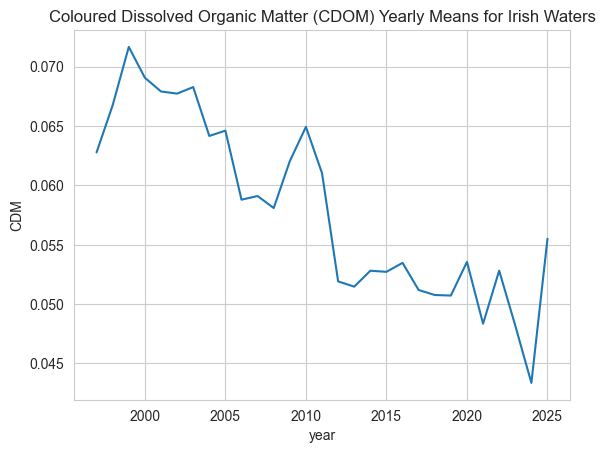

In [34]:
cdom_year_mean = cdom_ds['CDM'].mean(dim=['latitude', 'longitude']).groupby('time.year').mean(dim='time')
cdom_year_mean.plot()
plt.title('Coloured Dissolved Organic Matter (CDOM) Yearly Means for Irish Waters')
plt.show()

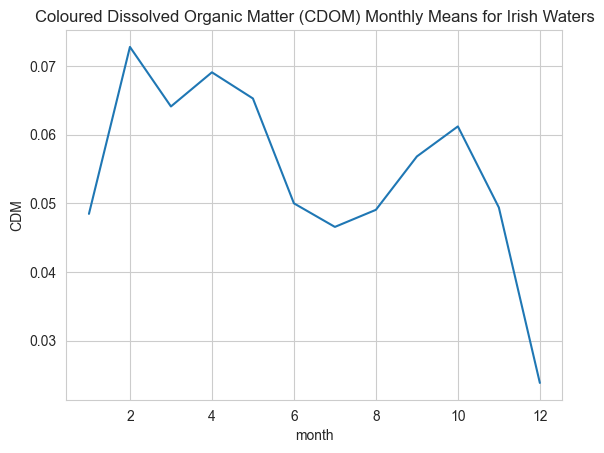

In [35]:
cdom_month_mean = cdom_ds['CDM'].mean(dim=['latitude', 'longitude']).groupby('time.month').mean(dim='time')
cdom_month_mean.plot()
plt.title('Coloured Dissolved Organic Matter (CDOM) Monthly Means for Irish Waters')
plt.show()

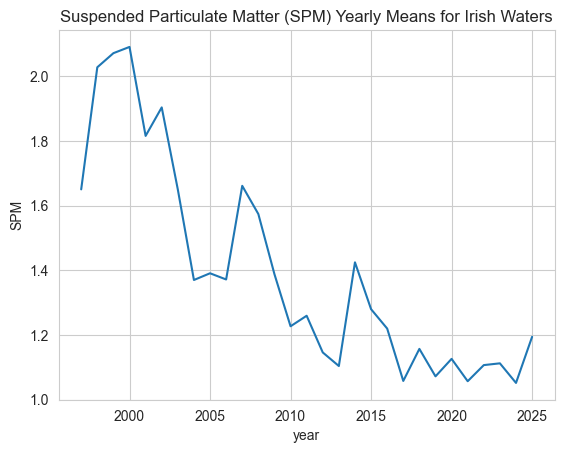

In [36]:
spm_year_mean = spm_ds['SPM'].mean( dim=['latitude', 'longitude']).groupby('time.year').mean(dim='time')
spm_year_mean.plot()
plt.title('Suspended Particulate Matter (SPM) Yearly Means for Irish Waters')
plt.show()

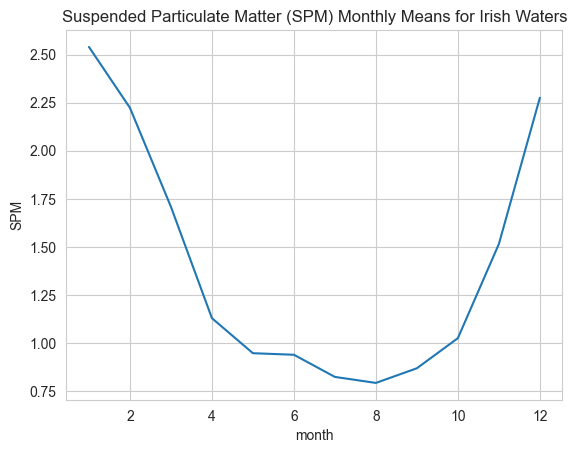

In [37]:
spm_month_mean = spm_ds['SPM'].mean( dim=['latitude', 'longitude']).groupby('time.month').mean(dim='time')
spm_month_mean.plot()
plt.title('Suspended Particulate Matter (SPM) Monthly Means for Irish Waters')
plt.show()

**looking at the monthly mean over the years, so it will be monthly values but for the whole time series**

In [38]:

monthly_chla_mean = monthly_chla.mean(dim=['latitude', 'longitude'], skipna=True)
monthly_kd490_mean = monthly_kd490.mean(dim=['latitude', 'longitude'], skipna=True)
monthly_cdom_mean = monthly_cdom.mean(dim=['latitude', 'longitude'], skipna=True)
monthly_spm_mean = monthly_spm.mean(dim=['latitude', 'longitude'], skipna=True)

In [39]:

chla_m = monthly_chla_mean
kd_m = monthly_kd490_mean
cdom_m = monthly_cdom_mean
spm_m  = monthly_spm_mean

Text(0, 0.5, 'Value')

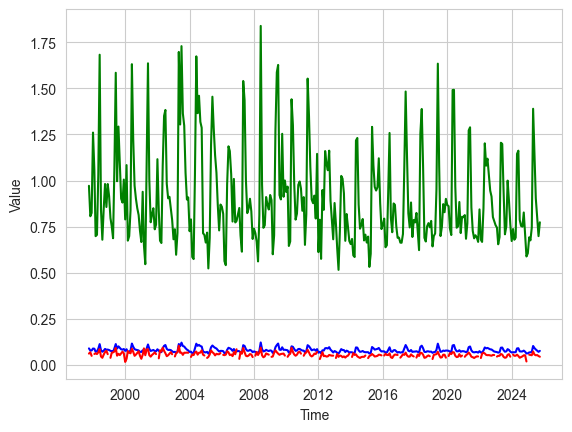

In [40]:
## can skip remaking this plot with SPM
plt.plot(kd_m['time'], kd_m, label='KD490', color='blue')
plt.plot(cdom_m['time'], cdom_m, label='CDM', color='red')
plt.plot(chla_m['time'], chla_m, label='CHL', color='green')
plt.xlabel('Time')
plt.ylabel('Value')

KeyboardInterrupt: 

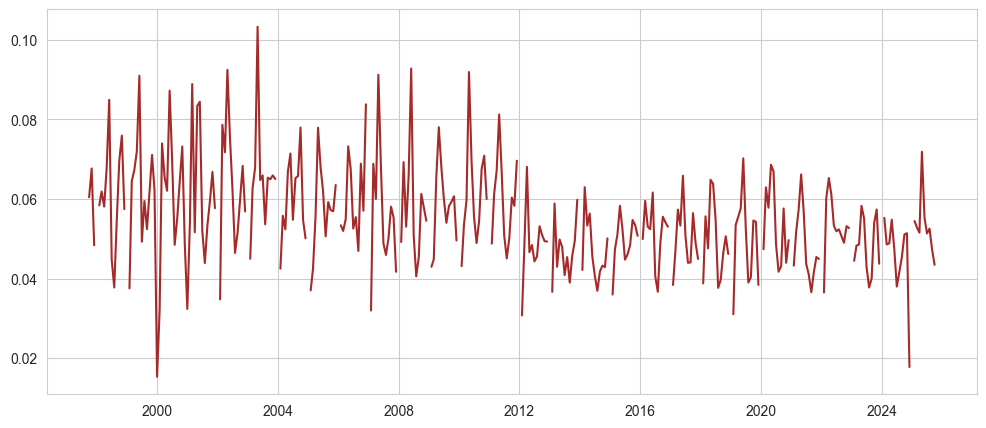

In [41]:
fig, ax1 = plt.subplots(figsize=(12,5))

# Plot CDOM and KD490 on left axis
ax1.plot(cdom_m['time'], cdom_m, color='brown', label='CDOM')
ax1.plot(kd_m['time'], kd_m, color='blue', label='KD490')
ax1.set_ylabel('CDOM / KD490 (m-3)', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Plot Chlorophyll on right axis
ax2 = ax1.twinx()
ax2.plot(chla_m['time'], chla_m, color='green', label='CHL')
ax2.plot(spm_m['time'], spm_m, color='red', label='SPM')
ax2.set_ylabel('Chlorophyll (mg m-3)/ SPM (g m-3)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('CDOM, KD490, SPM, and Chlorophyll Monthly Mean')
plt.grid(alpha=0.3)
plt.show()


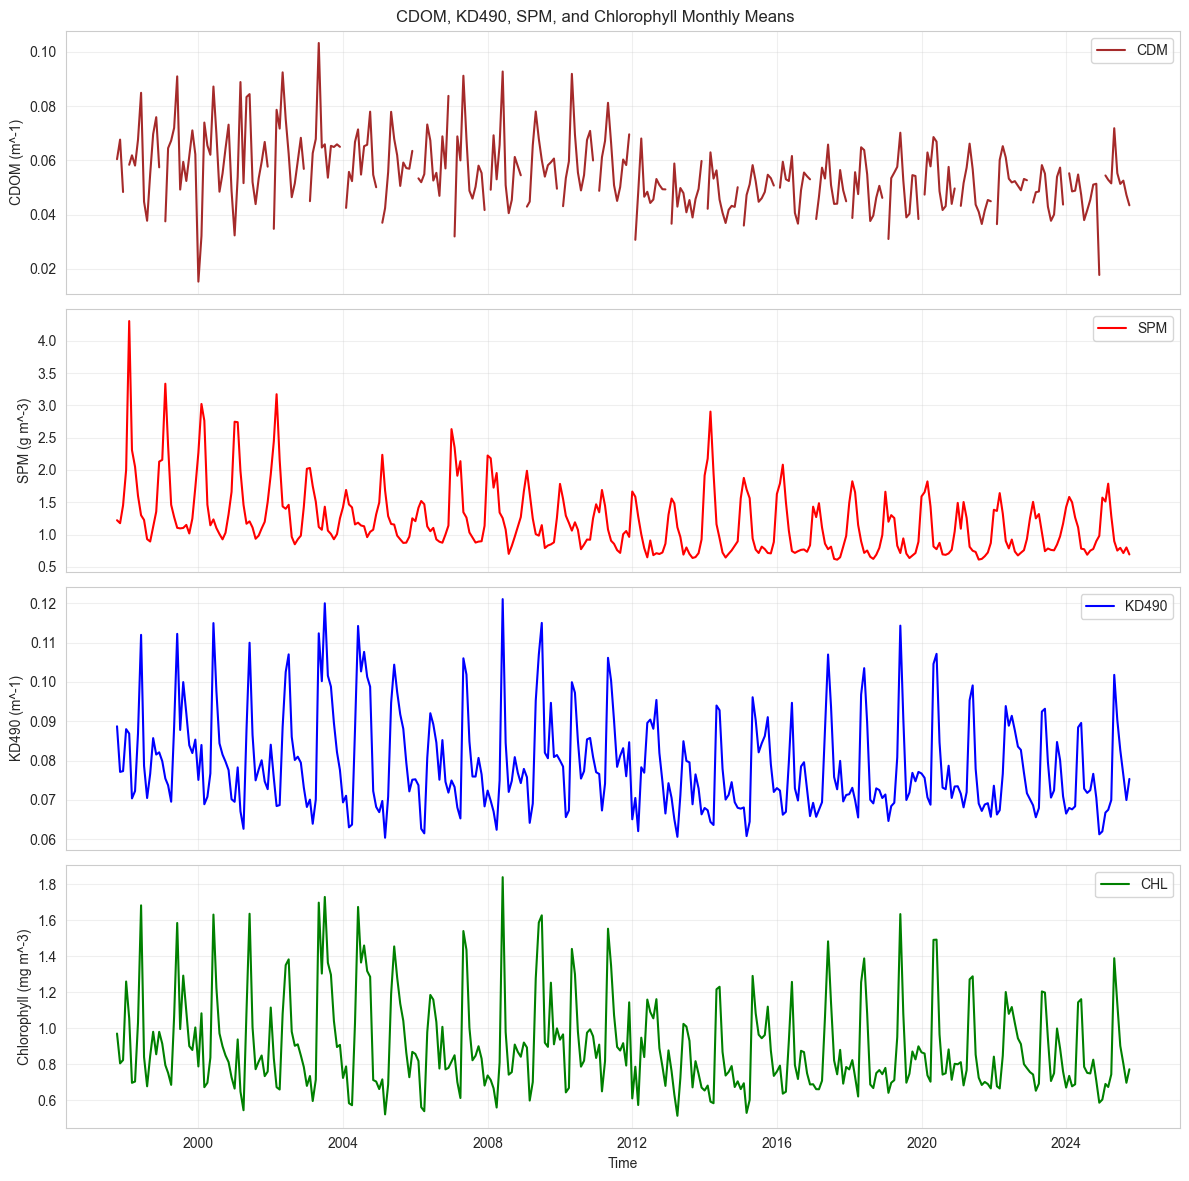

In [43]:
fig, axes = plt.subplots(4,1,figsize=(12,12), sharex=True)

## cdom
axes[0].plot(cdom_m['time'], cdom_m, color='brown', label='CDM')
axes[0].set_ylabel('CDOM (m^-1)')
axes[0].legend()
axes[0].grid(alpha=0.3)

## spm
axes[1].plot(spm_m['time'], spm_m, color='red', label='SPM')
axes[1].set_ylabel('SPM (g m^-3)')
axes[1].legend()
axes[1].grid(alpha=0.3)

## kd490
axes[2].plot(kd_m['time'], kd_m, color='blue', label='KD490')
axes[2].set_ylabel('KD490 (m^-1)')
axes[2].legend()
axes[2].grid(alpha=0.3)

## chl
axes[3].plot(chla_m['time'], chla_m, color='green', label='CHL')
axes[3].set_ylabel('Chlorophyll (mg m^-3)')
axes[3].legend()
axes[3].grid(alpha=0.3)

axes[3].set_xlabel('Time')


plt.suptitle('CDOM, KD490, SPM, and Chlorophyll Monthly Means')
plt.tight_layout()
fig.savefig('CDOM_KD490_Chla_SPM_TimeSeries_monthlymean.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
## need to go back and add skipna=True and min_count=1 to the monthly resampling and the mean functions - CDOM missing months of data
## i did this and nothing really changed on the CDOM map

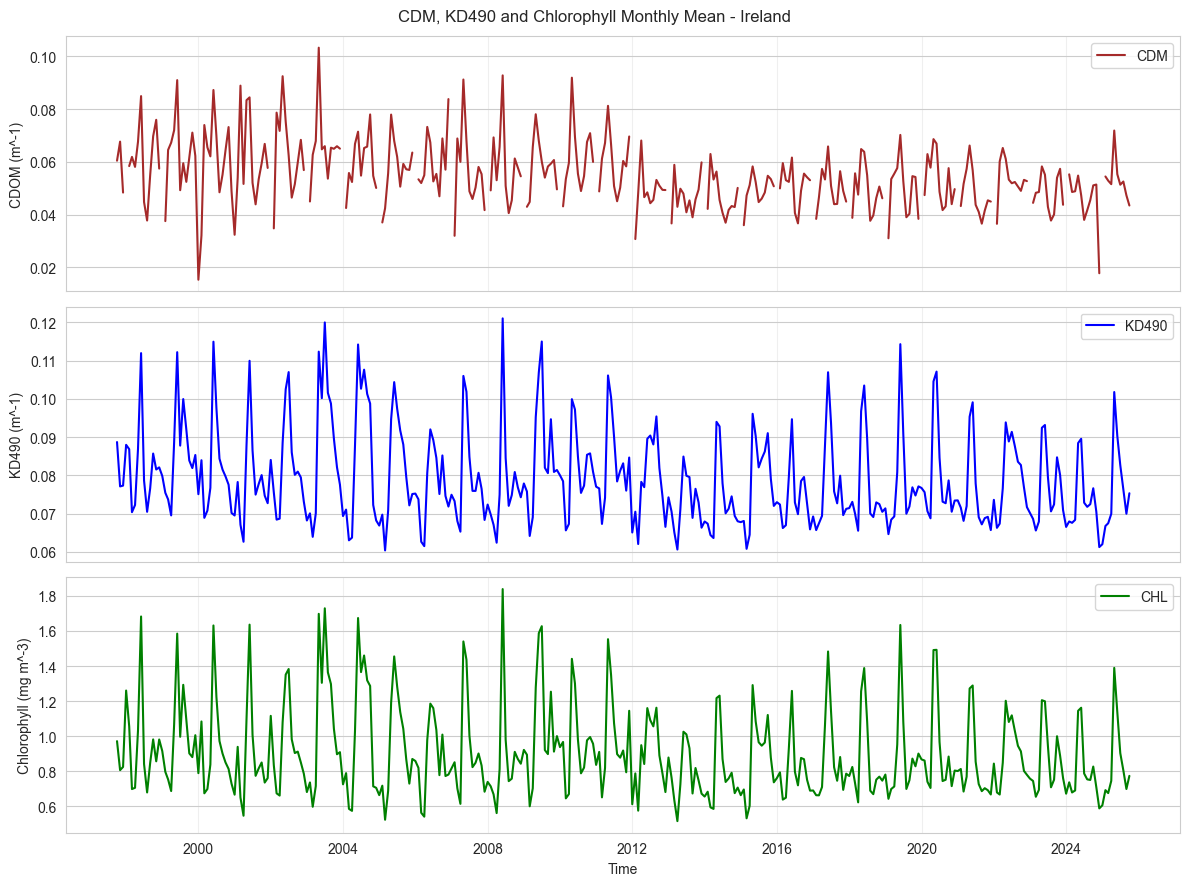

In [80]:
## don't need to alter this for SPM, only change was for the grid and it didn't do what I wanted anyways
fig, axes = plt.subplots(3,1,figsize=(12,9), sharex=True)

## cdom
axes[0].plot(cdom_m['time'], cdom_m, color='brown', label='CDM')
axes[0].set_ylabel('CDOM (m^-1)')
axes[0].legend()
axes[0].grid(alpha=0.3, which='both',axis='x')

## kd490
axes[1].plot(kd_m['time'], kd_m, color='blue', label='KD490')
axes[1].set_ylabel('KD490 (m^-1)')
axes[1].legend()
axes[1].grid(alpha=0.3,which='both',axis='x')

## chl
axes[2].plot(chla_m['time'], chla_m, color='green', label='CHL')
axes[2].set_ylabel('Chlorophyll (mg m^-3)')
axes[2].legend()
axes[2].grid(alpha=0.3,which='both',axis='x')

axes[2].set_xlabel('Time')

plt.suptitle('CDM, KD490 and Chlorophyll Monthly Mean - Ireland')
plt.tight_layout()
fig.savefig('CDOM_KD490_Chla_TimeSeries_monthlymean.png')
plt.show()

## What days had the highest CDOM Concentrations in West Coast Ireland?

In [18]:
max_cdom_sorted = cdom_ds.sortby(cdom_ds['CDM'].max(dim=('latitude','longitude')), ascending=False)
max_cdom_sorted

<xarray.Dataset> Size: 54GB
Dimensions:    (time: 10228, latitude: 1056, longitude: 1248)
Coordinates:
  * time       (time) datetime64[ns] 82kB 2025-01-23 2025-01-21 ... 2024-01-28
  * latitude   (latitude) float32 4kB 48.01 48.02 48.03 ... 58.97 58.98 58.99
  * longitude  (longitude) float32 5kB -14.99 -14.98 -14.97 ... -2.016 -2.005
Data variables:
    CDM        (time, latitude, longitude) float32 54GB dask.array<chunksize=(352, 1056, 1248), meta=np.ndarray>
Attributes:
    contact:                   servicedesk.cmems@acri-st.fr
    Conventions:               CF-1.8, ACDD-1.3
    source:                    surface observation
    institution:               ACRI
    title:                     cmems_obs-oc_atl_bgc-optics_my_l3-multi-1km_P1D
    history:                   Created using software developed at ACRI-ST
    comment:                   average
    references:                http://www.globcolour.info GlobColour has been...
    copernicusmarine_version:  2.2.2

In [22]:
max_cdom_sorted['time'].isel(time=slice(0,50))

<xarray.DataArray 'time' (time: 50)> Size: 400B
array(['2025-01-23T00:00:00.000000000', '2025-01-21T00:00:00.000000000',
       '2025-01-19T00:00:00.000000000', '2025-01-18T00:00:00.000000000',
       '2025-01-17T00:00:00.000000000', '2025-01-16T00:00:00.000000000',
       '2025-01-14T00:00:00.000000000', '2025-01-13T00:00:00.000000000',
       '2025-01-12T00:00:00.000000000', '2025-01-11T00:00:00.000000000',
       '2025-01-10T00:00:00.000000000', '2025-01-09T00:00:00.000000000',
       '2025-01-08T00:00:00.000000000', '2025-01-07T00:00:00.000000000',
       '2025-01-06T00:00:00.000000000', '2025-01-05T00:00:00.000000000',
       '2025-01-04T00:00:00.000000000', '2025-01-03T00:00:00.000000000',
       '2025-01-02T00:00:00.000000000', '2025-01-01T00:00:00.000000000',
       '2024-12-31T00:00:00.000000000', '2024-12-30T00:00:00.000000000',
       '2024-12-29T00:00:00.000000000', '2024-12-28T00:00:00.000000000',
       '2024-12-27T00:00:00.000000000', '2024-12-26T00:00:00.000000000',
       '2024-12-25T00:00:00.000000000', '2024-12-24T00:00:00.000000000',
       '2024-12-23T00:00:00.000000000', '2024-12-22T00:00:00.000000000',
       '2024-12-21T00:00:00.000000000', '2024-12-20T00:00:00.000000000',
       '2024-12-19T00:00:00.000000000', '2024-12-18T00:00:00.000000000',
       '2024-12-17T00:00:00.000000000', '2024-12-16T00:00:00.000000000',
       '2024-12-15T00:00:00.000000000', '2024-12-14T00:00:00.000000000',
       '2024-12-13T00:00:00.000000000', '2024-12-12T00:00:00.000000000',
       '2024-12-11T00:00:00.000000000', '2024-12-10T00:00:00.000000000',
       '2024-12-09T00:00:00.000000000', '2024-12-08T00:00:00.000000000',
       '2024-12-07T00:00:00.000000000', '2024-12-06T00:00:00.000000000',
       '2024-12-05T00:00:00.000000000', '2024-12-04T00:00:00.000000000',
       '2024-12-03T00:00:00.000000000', '2024-12-02T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 400B 2025-01-23 2025-01-21 ... 2024-12-02
Attributes:
    axis:           T
    unit_long:      Days Since 1900-01-01
    long_name:      Time
    standard_name:  time

**In the block shown above, we can see that the highest values all appear in 2025, then 2024. But this is the whole lat/long range, which includes the Irish and Celtic Seas. What about just west coast ireland?**

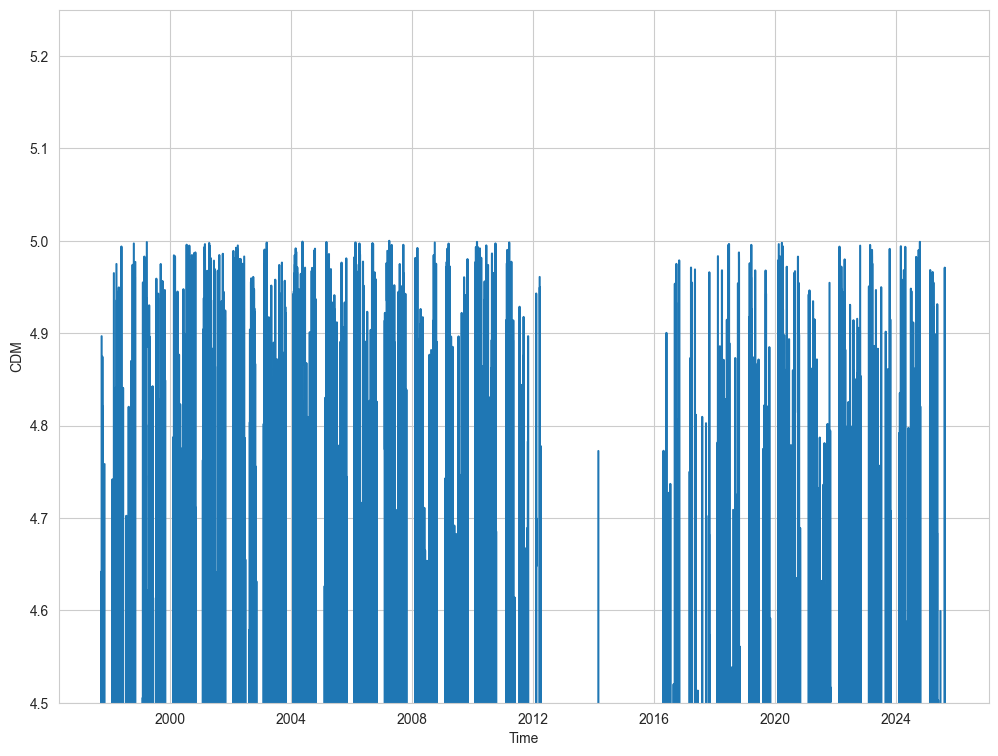

In [37]:
plt.figure(figsize=(12,9))
cdom_ds['CDM'].sel(latitude=slice(51.25,55.5),longitude=slice(-11,-7)).max(dim=('latitude','longitude')).plot()
plt.ylim(4.5,5.25)
plt.show()

In [55]:
west_cdom_ds = cdom_ds.sel(latitude=slice(51.25,55.5),longitude=slice(-11,-6.5))
west_max_cdom_sorted = west_cdom_ds.sortby(west_cdom_ds['CDM'].max(dim=('latitude','longitude')), ascending=False)

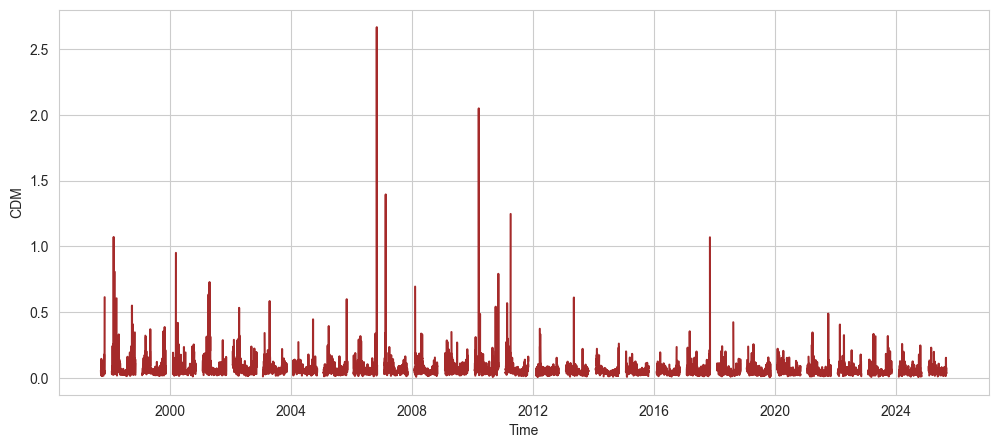

In [47]:
plt.figure(figsize=(12,5))
west_cdom_ds['CDM'].mean(dim=('latitude','longitude')).plot(color='brown')
plt.show()

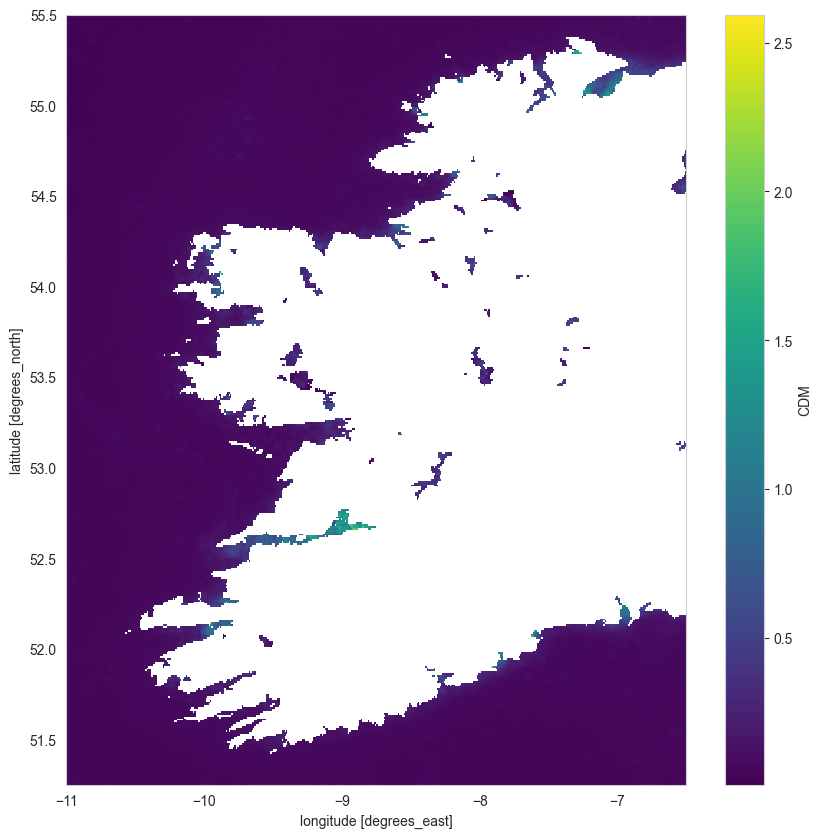

In [56]:
plt.figure(figsize=(10,10))
west_cdom_ds['CDM'].sel(latitude=slice(51.25,55.5),longitude=slice(-11,-6), time=slice('9-4-2024','9-4-2025')).mean(dim=('time')).plot()
plt.show()

## Dates of Spring Bloom

In [58]:
chla_ds

<xarray.Dataset> Size: 54GB
Dimensions:    (time: 10228, latitude: 1056, longitude: 1248)
Coordinates:
  * time       (time) datetime64[ns] 82kB 1997-09-04 1997-09-05 ... 2025-09-04
  * latitude   (latitude) float32 4kB 48.01 48.02 48.03 ... 58.97 58.98 58.99
  * longitude  (longitude) float32 5kB -14.99 -14.98 -14.97 ... -2.016 -2.005
Data variables:
    CHL        (time, latitude, longitude) float32 54GB dask.array<chunksize=(119, 1056, 1248), meta=np.ndarray>
Attributes:
    institution:               ACRI
    comment:                   average
    contact:                   servicedesk.cmems@acri-st.fr
    source:                    surface observation
    history:                   Created using software developed at ACRI-ST
    Conventions:               CF-1.8, ACDD-1.3
    title:                     cmems_obs-oc_atl_bgc-plankton_my_l3-multi-1km_P1D
    references:                http://www.globcolour.info GlobColour has been...
    copernicusmarine_version:  2.2.2

# Kd490 and Secchi Depths Comparison

Current Idea: Take the Latitude, Longitude, and Dates that I have for valid Secchi Data for Coastal Ireland, and pull those numbers from Kd490 data, see what I get
secchi_right.csv comes from the Secchi_Depths.ipynb notebook analysis from ICES data.

In [81]:
secchi = pd.read_csv('/Users/25298423/PycharmProjects/JupyterProject1/secchi_right.csv')
secchi

,cruise,station,time,latitude_degN,longitude_degE,bottom_depth_m,secchi_depth_m,year
0,411,1001-1,2022-03-02 16:36:00+00:00,51.722961,-8.612848,4.9,0.30,2022
1,411,1001-1,2023-02-02 14:43:00+00:00,51.722960,-8.612850,4.9,2.25,2023
2,411,1001-2,2022-05-16 07:26:00+00:00,51.722961,-8.612848,5.6,1.00,2022
3,411,1001-2,2023-06-22 09:41:00+00:00,51.722960,-8.612850,4.0,1.25,2023
4,411,1001-3,2022-07-06 11:53:00+00:00,51.722961,-8.612848,4.6,1.25,2022
...,...,...,...,...,...,...,...,...
19539,4599,Y100,2014-01-13 09:56:00+00:00,52.982200,-6.032500,4.0,0.90,2014
19540,4599,Y100,2014-06-19 12:29:00+00:00,52.982200,-6.032500,3.0,1.50,2014
19541,4599,Y100,2014-07-31 13:13:00+00:00,52.982200,-6.032500,4.0,3.20,2014
19542,4599,Y220,2014-05-19 13:13:00+00:00,52.346200,-6.470200,6.0,0.40,2014


In [82]:
all_ds

<xarray.Dataset> Size: 54GB
Dimensions:      (time: 10228, y: 1056, x: 1248)
Coordinates:
  * time         (time) datetime64[ns] 82kB 1997-09-04 1997-09-05 ... 2025-09-04
  * y            (y) float32 4kB 48.01 48.02 48.03 48.04 ... 58.97 58.98 58.99
  * x            (x) float32 5kB -14.99 -14.98 -14.97 ... -2.026 -2.016 -2.005
    spatial_ref  int64 8B 0
Data variables:
    KD490        (time, y, x) float32 54GB dask.array<chunksize=(119, 1056, 1248), meta=np.ndarray>
Attributes:
    references:                http://www.globcolour.info GlobColour has been...
    contact:                   servicedesk.cmems@acri-st.fr
    Conventions:               CF-1.8, ACDD-1.3
    source:                    surface observation
    history:                   Created using software developed at ACRI-ST
    comment:                   average
    institution:               ACRI
    title:                     cmems_obs-oc_atl_bgc-transp_my_l3-multi-1km_P1D
    copernicusmarine_version:  2.2.2

In [83]:
secchi.rename(columns={'latitude_degN':'latitude','longitude_degE':'longitude'}, inplace=True)
secchi.dtypes

cruise              int64
station            object
time               object
latitude          float64
longitude         float64
bottom_depth_m    float64
secchi_depth_m    float64
year                int64
dtype: object

In [88]:
secchi['latitude'] = secchi['latitude'].astype('float32')
secchi['longitude'] = secchi['longitude'].astype('float32')
secchi['time'] = pd.to_datetime(secchi['time'], utc=True)

In [92]:
kd_daily = all_ds['KD490'].sel(
    time= xr.DataArray(secchi['time'], dims='points'),
    method='nearest'
)

In [93]:
xr.DataArray(secchi['date'], dims='points')

KeyError: 'date'

In [91]:
kd_interp = kd_daily.interp(
    latitude=('points', secchi['latitude']),
    longitude=('points', secchi['longitude'])
)

ValueError: Dimensions {'latitude', 'longitude'} do not exist. Expected one or more of FrozenMappingWarningOnValuesAccess({'y': 1056, 'x': 1248, 'points': 19544})

nan_mask = kd_interp.isnull()

nan_points = nan_mask.compute().values

if nan_points.any():

    kd_fallback = kd_daily.sel(
        latitude = xr.DataArray(secchi['latitude'][nan_points], dims='points'),
        longitude = xr.DataArray(secchi['longitude'][nan_points], dims='points'),
        method='nearest'
    )

    kd_interp = kd_interp.where(~nan_mask, kd_fallback)

secchi['Kd490_match'] = kd_interp.compute().to_pandas()

In [94]:
secchi['date'] = secchi['time'].dt.date
secchi['date'] = pd.to_datetime(secchi['date'], utc=True)

In [95]:
secchi.dtypes

cruise                          int64
station                        object
time              datetime64[ns, UTC]
latitude                      float32
longitude                     float32
bottom_depth_m                float64
secchi_depth_m                float64
year                            int64
date              datetime64[ns, UTC]
dtype: object

In [96]:
secchi

,cruise,station,time,latitude,longitude,bottom_depth_m,secchi_depth_m,year,date
0,411,1001-1,2022-03-02 16:36:00+00:00,51.722961,-8.612848,4.9,0.30,2022,2022-03-02 00:00:00+00:00
1,411,1001-1,2023-02-02 14:43:00+00:00,51.722961,-8.612850,4.9,2.25,2023,2023-02-02 00:00:00+00:00
2,411,1001-2,2022-05-16 07:26:00+00:00,51.722961,-8.612848,5.6,1.00,2022,2022-05-16 00:00:00+00:00
3,411,1001-2,2023-06-22 09:41:00+00:00,51.722961,-8.612850,4.0,1.25,2023,2023-06-22 00:00:00+00:00
4,411,1001-3,2022-07-06 11:53:00+00:00,51.722961,-8.612848,4.6,1.25,2022,2022-07-06 00:00:00+00:00
...,...,...,...,...,...,...,...,...,...
19539,4599,Y100,2014-01-13 09:56:00+00:00,52.982201,-6.032500,4.0,0.90,2014,2014-01-13 00:00:00+00:00
19540,4599,Y100,2014-06-19 12:29:00+00:00,52.982201,-6.032500,3.0,1.50,2014,2014-06-19 00:00:00+00:00
19541,4599,Y100,2014-07-31 13:13:00+00:00,52.982201,-6.032500,4.0,3.20,2014,2014-07-31 00:00:00+00:00
19542,4599,Y220,2014-05-19 13:13:00+00:00,52.346199,-6.470200,6.0,0.40,2014,2014-05-19 00:00:00+00:00


In [97]:
kd_match = all_ds['KD490'].sel(
    time = xr.DataArray(secchi['date'], dims='points'),
    latitude = xr.DataArray(secchi['latitude'], dims='points'),
    longitude = xr.DataArray(secchi['longitude'], dims='points'),
    method='nearest'
)

KeyError: "'latitude' is not a valid dimension or coordinate for Dataset with dimensions FrozenMappingWarningOnValuesAccess({'y': 1056, 'x': 1248, 'time': 10228})"

In [98]:

# Compute lat/lon differences
lat_diff = np.abs(kd_match['latitude'].values - secchi['latitude'].values)
lon_diff = np.abs(kd_match['longitude'].values - secchi['longitude'].values)

# Mask for distance <= 0.2° and exact date match
time_diff = np.abs(kd_match['time'].values - secchi['date'].values)
mask = (lat_diff <= 0.005) & (lon_diff <= 0.005) & (time_diff == np.timedelta64(0, 'D'))

# Apply mask
kd_match_filtered = kd_match.where(mask, drop=False)

NameError: name 'kd_match' is not defined

In [99]:
secchi['Kd490_lat'] = kd_match_filtered['latitude'].values
secchi['Kd490_lon'] = kd_match_filtered['longitude'].values
secchi['Kd490_date'] = kd_match_filtered['time'].values


NameError: name 'kd_match_filtered' is not defined

In [100]:
secchi['Kd490_match'] = kd_match_filtered.compute().to_pandas()

NameError: name 'kd_match_filtered' is not defined

In [101]:
secchi_valid = secchi.dropna(subset=['Kd490_match'])
secchi_valid

KeyError: ['Kd490_match']

In [102]:
secchi_valid['lat_diff'] = secchi_valid['latitude'] - secchi_valid['Kd490_lat']
secchi_valid['lon_diff'] = secchi_valid['longitude'] - secchi_valid['Kd490_lon']
secchi_valid['dist_meas'] = np.sqrt(secchi_valid['lat_diff']**2 + secchi_valid['lon_diff']**2)
secchi_valid

NameError: name 'secchi_valid' is not defined

In [103]:
secchi_valid.sort_values(by='dist_meas', ascending=False)

NameError: name 'secchi_valid' is not defined

In [104]:
all_ds.sel(time=datetime(2023,1,30), latitude = 51.912373, longitude = -7.83898, method='nearest').compute().values

KeyError: "'latitude' is not a valid dimension or coordinate for Dataset with dimensions FrozenMappingWarningOnValuesAccess({'time': 10228, 'y': 1056, 'x': 1248})"

In [105]:
plt.figure(figsize=(10,5))
plt.scatter( secchi_valid['Kd490_match'], secchi_valid['secchi_depth_m'])

plt.xlabel( 'Kd490 (m^-1)')
plt.ylabel( 'Secchi Depth (m)')
plt.title('Correlation between Secchi Depth and Kd490 Values')
plt.savefig('correlation_secchi_kd490_val.png')
plt.show()

NameError: name 'secchi_valid' is not defined

<Figure size 1000x500 with 0 Axes>

In [106]:
plt.figure(figsize=(10,5))
plt.scatter(  secchi_valid['secchi_depth_m'],secchi_valid['Kd490_match'])
plt.yscale('log', base=np.e)
plt.xscale('log', base=np.e)
plt.ylabel( 'ln(Kd490) (m^-1)')
plt.ylabel( 'ln(Secchi Depth) (m)')
plt.title('Correlation between Secchi Depth and Kd490 Values')
plt.savefig('correlation_secchi_kd490_lognatural_val.png')
plt.show()

NameError: name 'secchi_valid' is not defined

<Figure size 1000x500 with 0 Axes>

In [107]:
secchi_valid = secchi_valid.sort_values(by='time', ascending=True)
secchi_valid

NameError: name 'secchi_valid' is not defined

In [108]:
plt.plot(secchi_valid['time'], secchi_valid['secchi_depth_m'])
plt.plot(secchi_valid['time'], secchi_valid['Kd490_match'])
plt.show()

NameError: name 'secchi_valid' is not defined

NameError: name 'secchi_valid' is not defined

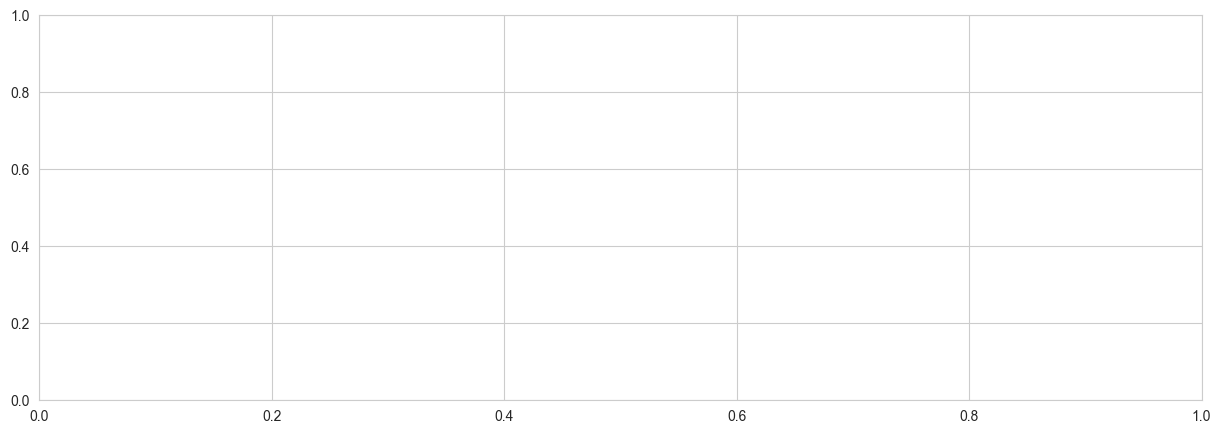

In [109]:
fig, ax1 = plt.subplots(figsize=(15,5))

ax1.plot(secchi_valid['time'], secchi_valid['secchi_depth_m'], color='blue', label='Secchi Depth')
ax1.set_ylabel('Secchi Depth (m)', color='blue')

ax2 = ax1.twinx()
ax2.plot(secchi_valid['time'], secchi_valid['Kd490_match'], color='green', label='KD490')
ax2.invert_yaxis()
ax2.set_ylabel('KD490 (m^-1)', color='green')

plt.show()

NameError: name 'secchi_valid' is not defined

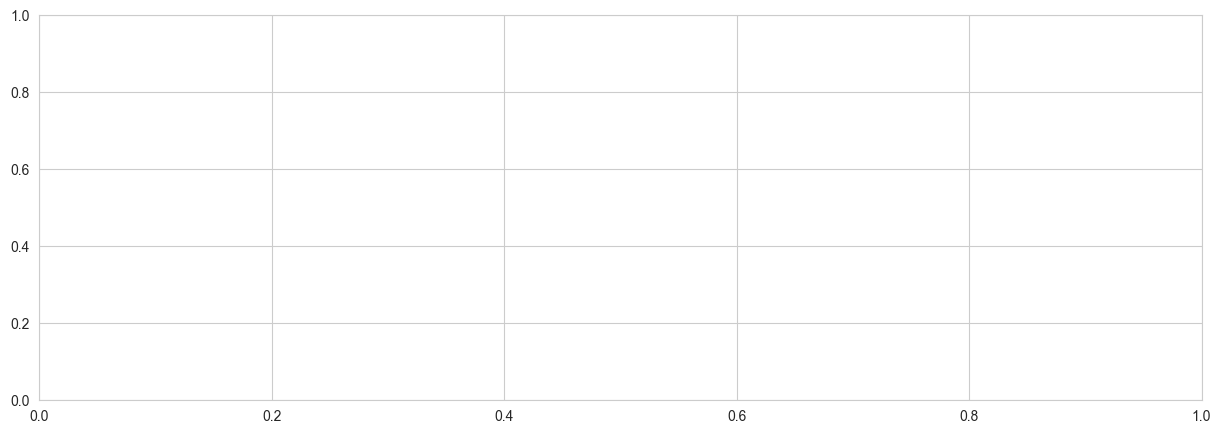

In [110]:
fig, ax1 = plt.subplots(figsize=(15,5))

ax1.scatter(secchi_valid['time'], secchi_valid['secchi_depth_m'], color='blue', label='Secchi Depth')
ax1.set_ylabel('Secchi Depth (m)', color='blue')

ax2 = ax1.twinx()
ax2.scatter(secchi_valid['time'], secchi_valid['Kd490_match'], color='green', label='KD490')
ax2.invert_yaxis()
ax2.set_ylabel('KD490 (m^-1)', color='green')

plt.savefig('secchi_kd490_values_timeline.png')
plt.show()

In [111]:
# Normalize Secchi and Kd490
secchi_valid['secchi_norm'] = (secchi_valid['secchi_depth_m'] - secchi_valid['secchi_depth_m'].min()) / (secchi_valid['secchi_depth_m'].max() - secchi_valid['secchi_depth_m'].min())
secchi_valid['kd490_norm'] = 1 - (secchi_valid['Kd490_match'] - secchi_valid['Kd490_match'].min()) / (secchi_valid['Kd490_match'].max() - secchi_valid['Kd490_match'].min())  # inverted

# Plot
plt.figure(figsize=(12,5))
plt.scatter(secchi_valid['time'], secchi_valid['secchi_norm'], color='blue', label='Secchi depth')
plt.scatter(secchi_valid['time'], secchi_valid['kd490_norm'], color='green', label='Kd490 inverted')
plt.ylabel('Normalized values')
plt.legend()
plt.show()
## IDK if this is better or not, still hard to tell if there is any matchup at all

NameError: name 'secchi_valid' is not defined

# Try to get just coastal data for Kd490

In [112]:
## try to get this onto a map of Ireland using geopandas

url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_IRL_shp.zip"
uk_url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_GBR_shp.zip"

ireland = gpd.read_file(url, layer="gadm41_IRL_0")

uk = gpd.read_file(uk_url, layer="gadm41_GBR_0")
uk_regions = gpd.read_file(uk_url, layer="gadm41_GBR_1")
northern_ireland = uk_regions[uk_regions["NAME_1"] == "Northern Ireland"]
island = gpd.GeoDataFrame(pd.concat([ireland, northern_ireland], ignore_index=True), crs="EPSG:4326")

In [113]:
buffer_degrees = 0.1
## approximately coastal data

In [114]:
## use geopandas .buffer() function
coast_buffer = island.buffer(buffer_degrees)

C:\Users\25298423\AppData\Local\Temp\ipykernel_24712\3215575422.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coast_buffer = island.buffer(buffer_degrees)


In [115]:
## create a buffer geodataframe
buffer_gdf = gpd.GeoDataFrame(geometry=coast_buffer, crs="EPSG:4326").dissolve()

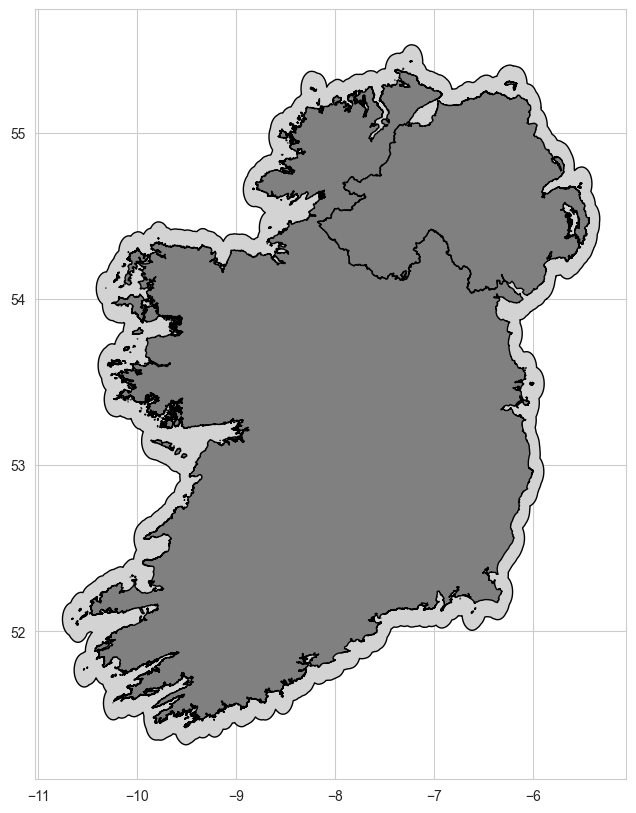

In [116]:
fig, ax = plt.subplots(figsize=(8, 10))

buffer_gdf.plot(ax=ax, color="lightgray", edgecolor="black")
island.plot(ax=ax, color='gray', edgecolor= 'black')

plt.show()

In [117]:
all_ds

<xarray.Dataset> Size: 54GB
Dimensions:      (time: 10228, y: 1056, x: 1248)
Coordinates:
  * time         (time) datetime64[ns] 82kB 1997-09-04 1997-09-05 ... 2025-09-04
  * y            (y) float32 4kB 48.01 48.02 48.03 48.04 ... 58.97 58.98 58.99
  * x            (x) float32 5kB -14.99 -14.98 -14.97 ... -2.026 -2.016 -2.005
    spatial_ref  int64 8B 0
Data variables:
    KD490        (time, y, x) float32 54GB dask.array<chunksize=(119, 1056, 1248), meta=np.ndarray>
Attributes:
    references:                http://www.globcolour.info GlobColour has been...
    contact:                   servicedesk.cmems@acri-st.fr
    Conventions:               CF-1.8, ACDD-1.3
    source:                    surface observation
    history:                   Created using software developed at ACRI-ST
    comment:                   average
    institution:               ACRI
    title:                     cmems_obs-oc_atl_bgc-transp_my_l3-multi-1km_P1D
    copernicusmarine_version:  2.2.2

In [118]:
all_ds = all_ds.rio.write_crs("EPSG:4326")

In [119]:
all_ds = all_ds.rename({'latitude':'y','longitude':'x'})

ValueError: cannot rename 'latitude' because it is not a variable or dimension in this dataset

In [120]:
coastal_mask_gdf = buffer_gdf.to_crs("EPSG:4326")

In [121]:
coastal_kd490 = all_ds.rio.clip(
    coastal_mask_gdf.geometry,
    coastal_mask_gdf.crs,
    drop=True
)

In [122]:
mean_coastal_kd490 = coastal_kd490['KD490'].mean(dim=['y','x'], skipna=True)

mean_coastal_kd490_computed = mean_coastal_kd490.compute()

In [123]:
mean_coastal_kd490_computed

<xarray.DataArray 'KD490' (time: 10228)> Size: 41kB
array([       nan,        nan,        nan, ..., 0.15965968, 0.12869032,
       0.18675496], shape=(10228,), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 82kB 1997-09-04 1997-09-05 ... 2025-09-04
    spatial_ref  int64 8B 0

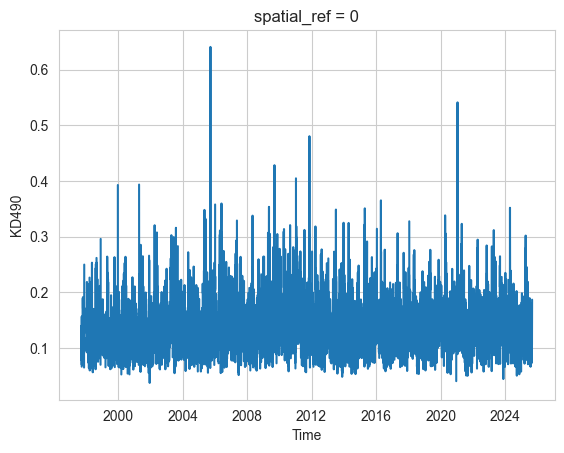

In [124]:
mean_coastal_kd490_computed.plot()

In [125]:
times = mean_coastal_kd490_computed.time.values
start_time = times[0]
time_numeric = np.array([(t - start_time).astype('timedelta64[D]').item().days for t in times])

In [126]:
kd490_values = mean_coastal_kd490_computed.values

In [127]:
valid_mask = ~np.isnan(kd490_values)
time_for_regression = time_numeric[valid_mask]
data_for_regression = kd490_values[valid_mask]

In [128]:
slope, intercept, r_value, p_value, std_err = linregress(time_for_regression, data_for_regression)

In [129]:
print("\n--- Temporal Trend Analysis ---")
print(f"Slope (Change in Kd490 per Day): {slope:.4e}")
print(f"P-value (Significance): {p_value:.4f}")
print(f"R-squared: {r_value**2:.4f}")

if p_value < 0.05:
    trend_direction = "increasing" if slope > 0 else "decreasing"
    print(f"\nThe Kd490 data along the coast shows a statistically significant ({p_value:.4f}) **{trend_direction}** trend over time.")
else:
    print(f"\nThe Kd490 data along the coast does not show a statistically significant trend (P-value > 0.05).")


--- Temporal Trend Analysis ---
Slope (Change in Kd490 per Day): 9.2585e-07
P-value (Significance): 0.0000
R-squared: 0.0037

The Kd490 data along the coast shows a statistically significant (0.0000) **increasing** trend over time.


In [130]:
stat_trend_ds = xr.open_dataset('KD490_trend_with_stats.nc')

In [131]:
stat_trend_ds = stat_trend_ds.rio.write_crs("EPSG:4326", inplace=True)

In [132]:
stat_trend_ds = stat_trend_ds.rename({'latitude':'y','longitude':'x'})

In [133]:
coastal_trend = stat_trend_ds.rio.clip(coastal_mask_gdf.geometry,
                                       coastal_mask_gdf.crs,
                                       drop=True)

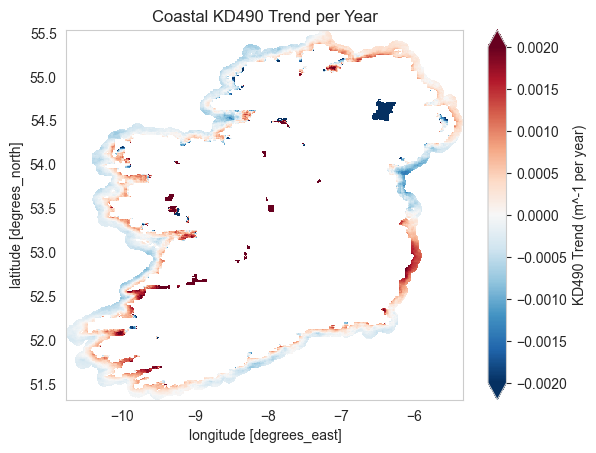

In [134]:
coastal_trend['slope'].plot(cmap='RdBu_r',
    center=0,
    vmin=-0.002, vmax=0.002,
    cbar_kwargs={'label': 'KD490 Trend (m^-1 per year)'}
)
plt.title('Coastal KD490 Trend per Year')

plt.savefig('Coastal_Weekly_Trend_KD490.png', dpi=600)
plt.show()

In [139]:
multi_algae_real = pd.read_csv("C:/Users/25298423/PycharmProjects/JupyterProject1/multi_algae_real.csv")

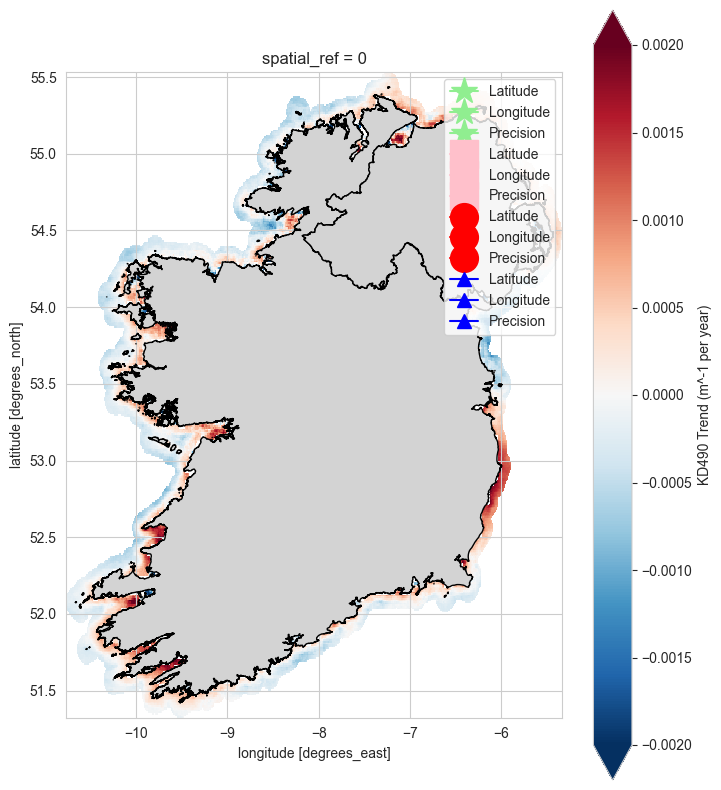

In [146]:
### DOES NOT WORK YET, NEED TO FIGURE OUT HOW TO GET ALGAE ON TOP
fig, ax = plt.subplots(figsize=(8, 10))



coastal_trend['slope'].plot(ax=ax,cmap='RdBu_r',
    center=0,
    vmin=-0.002, vmax=0.002,
    cbar_kwargs={'label': 'KD490 Trend (m^-1 per year)'},
    zorder=0
)

island.plot(ax=ax, color="lightgray", edgecolor="black",zorder=1)

multi_algae_real[multi_algae_real['Order'].str.contains('Other')].plot(ax=ax, color="lightgreen",marker = '*', markersize=20, label='Other',zorder=2)
multi_algae_real[multi_algae_real['Order'].str.contains('Corallinales')].plot(ax=ax, color="pink",marker = 's', markersize=20, label='Corallinales',zorder=2)
multi_algae_real[multi_algae_real['Order'].str.contains('Laminariales')].plot(ax=ax, color="red",marker = 'o', markersize=20, label = 'Laminariales',zorder=2)
multi_algae_real[multi_algae_real['Order'].str.contains('Fucales')].plot(ax=ax, color="blue", marker = '^', markersize=10, label='Fucales',zorder=2)
ax.legend()

plt.show()

In [137]:
## for February 3rd, need to get map and timeline of secchi disks

In [68]:
secchi

,cruise,station,time,latitude_degN,longitude_degE,bottom_depth_m,secchi_depth_m,year
0,411,1001-1,2022-03-02 16:36:00+00:00,51.722961,-8.612848,4.9,0.30,2022
1,411,1001-1,2023-02-02 14:43:00+00:00,51.722960,-8.612850,4.9,2.25,2023
2,411,1001-2,2022-05-16 07:26:00+00:00,51.722961,-8.612848,5.6,1.00,2022
3,411,1001-2,2023-06-22 09:41:00+00:00,51.722960,-8.612850,4.0,1.25,2023
4,411,1001-3,2022-07-06 11:53:00+00:00,51.722961,-8.612848,4.6,1.25,2022
...,...,...,...,...,...,...,...,...
19539,4599,Y100,2014-01-13 09:56:00+00:00,52.982200,-6.032500,4.0,0.90,2014
19540,4599,Y100,2014-06-19 12:29:00+00:00,52.982200,-6.032500,3.0,1.50,2014
19541,4599,Y100,2014-07-31 13:13:00+00:00,52.982200,-6.032500,4.0,3.20,2014
19542,4599,Y220,2014-05-19 13:13:00+00:00,52.346200,-6.470200,6.0,0.40,2014


NameError: name 'island' is not defined

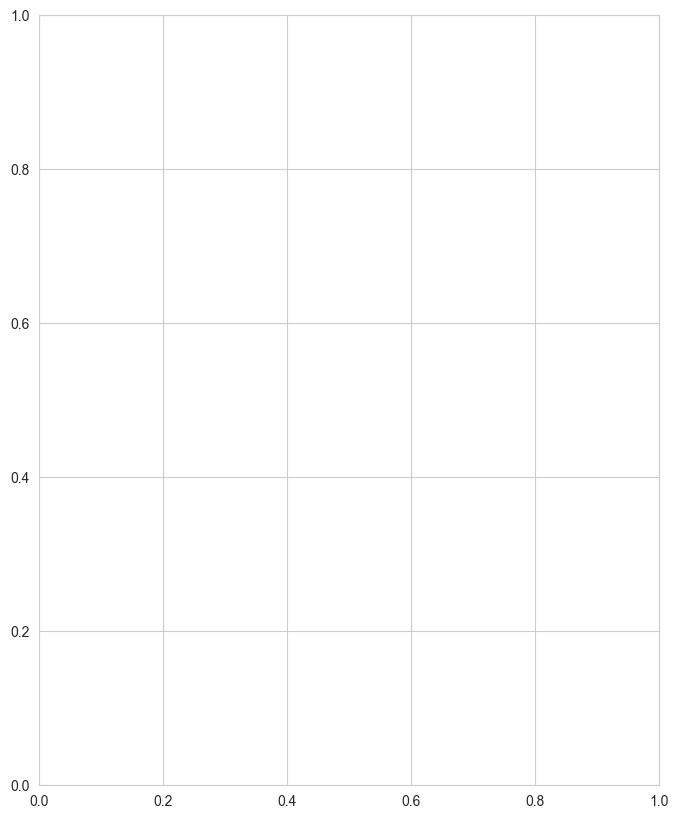

In [4]:
fig, ax = plt.subplots(figsize=(8, 10))

island.plot(ax=ax, color='lightgray', edgecolor= 'black')
sd = ax.scatter( secchi['longitude'], secchi['latitude'], c=secchi['secchi_depth_m'],
    cmap= 'plasma',
    s=20,
    alpha=0.8,
    vmin=0,
    vmax=20
)
ax.set_xlim(-11, -5)
ax.set_ylim(51, 56)

ax.set_title('Coastal Secchi Depth Data for Ireland')


plt.colorbar(sd, ax=ax, fraction=0.04, pad=0.05, label='Secchi Depth (m)')


plt.savefig('Coastal_Secchi_Depth_Map.png', dpi=600)
plt.show()

KeyError: 'date'

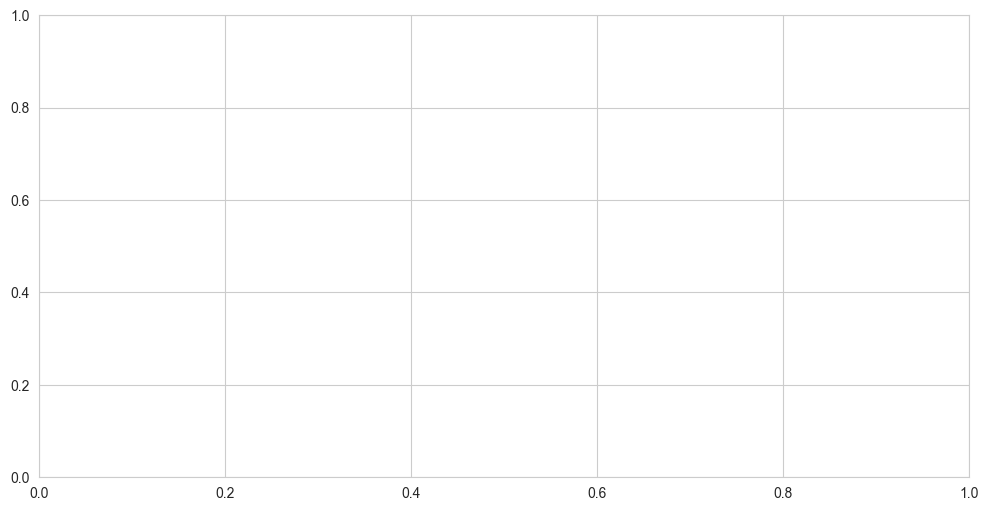

In [70]:

import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 6))
plt.scatter(secchi['date'],secchi['secchi_depth_m'])

# 2. Set the locator to find the first day of every year
ax.xaxis.set_major_locator(mdates.YearLocator())

# 3. Format the text labels to just show the Year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 4. Add the vertical gridlines
ax.grid(True, axis='x', linestyle='--', alpha=0.7)


plt.show()

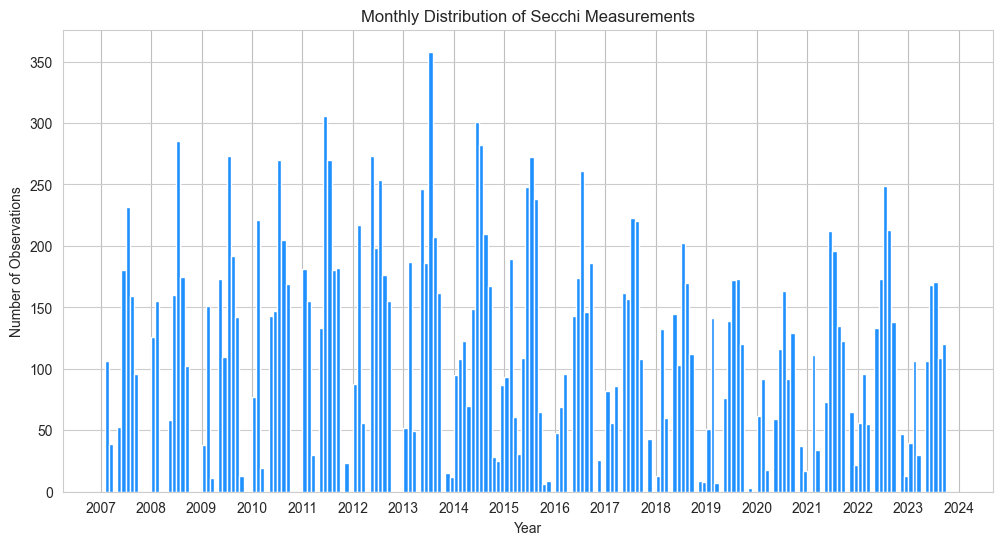

In [38]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 6))

## monthly bins
bin_edges = pd.date_range(start=secchi['date'].min(),
                          end=secchi['date'].max(),
                          freq='MS')
## actual histogram
ax.hist(secchi['date'], bins=bin_edges, color='dodgerblue', edgecolor='white')

## make sure every year has a line
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.5)

##labels
ax.set_ylabel('Number of Observations')
ax.set_xlabel('Year')
ax.set_title('Monthly Distribution of Secchi Measurements')

plt.savefig('Monthly_Count_Secchi_Depth.png', dpi=600)

plt.show()